# XGBoost full feature

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

import xgboost

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score

In [2]:
dataset = pd.read_csv("../../datasets/raw/diabetes_binary_health_indicators_BRFSS2015.csv" , sep = "," , encoding = 'utf-8')
print("Dataset Shape: ", dataset.shape)
dataset

Dataset Shape:  (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


## Clean Data

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

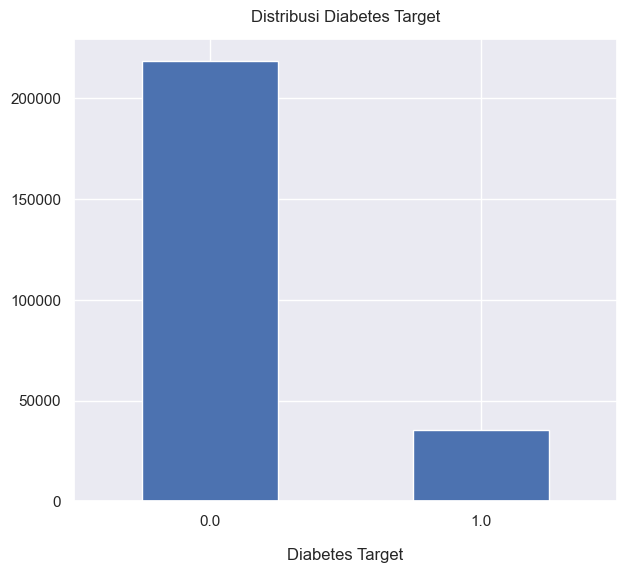

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


In [4]:
sns.set(font_scale=1.0)
dataset['Diabetes_binary'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)
plt.xlabel("Diabetes Target", labelpad=14)
plt.title("Distribusi Diabetes Target", y=1.02);
plt.show()

print(dataset['Diabetes_binary'].value_counts())

## Checking Missing Value

In [5]:
dataset.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

## Checking Duplicate Data

In [6]:
duplicate_rows = dataset.duplicated()
print("All Duplicate Rows:")
dataset[dataset.duplicated(keep=False)]

All Duplicate Rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


In [7]:
dataClean = dataset.drop_duplicates()
print("All Duplicate Rows:")
dataClean[dataClean.duplicated(keep=False)]

All Duplicate Rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [9]:
dataClean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229474 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  GenHlth               229474 non-null  float64
 15  MentH

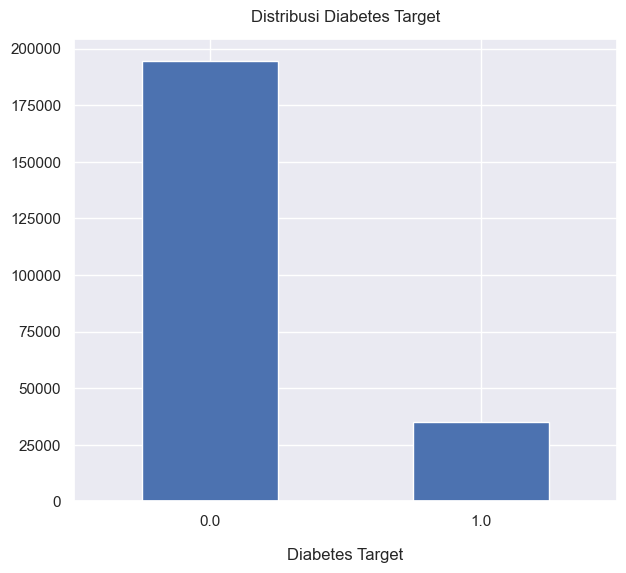

Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64


In [10]:
sns.set(font_scale=1.0)
dataClean['Diabetes_binary'].value_counts().plot(kind='bar', figsize=(7, 6), rot=0)
plt.xlabel("Diabetes Target", labelpad=14)
plt.title("Distribusi Diabetes Target", y=1.02);
plt.show()

print(dataClean['Diabetes_binary'].value_counts())

# Balancing Data

In [14]:
X = dataClean.drop(['Diabetes_binary'], axis = 1).values
y = dataClean['Diabetes_binary']

## Over-Sampling SMOTE

In [15]:
# SMOTE
smote = SMOTE(random_state=42)
X_resampled_smote, y_resampled_smote = SMOTE().fit_resample(X, y)

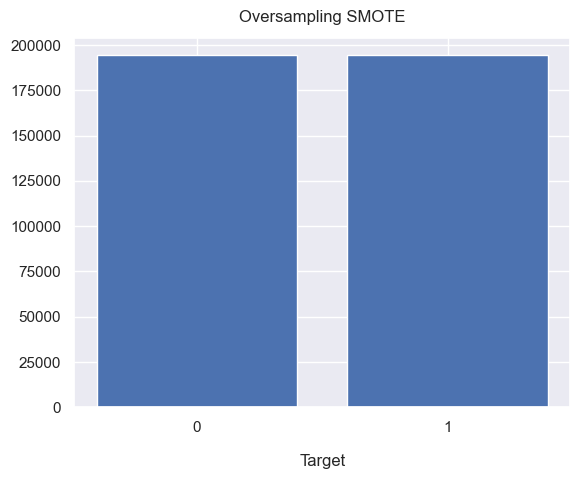

Diabetes_binary
0.0    194377
1.0    194377
Name: count, dtype: int64

In [16]:
# Oversampling SMOTE
sns.set(font_scale=1.0)
smote_counts = y_resampled_smote.value_counts()

plt.bar(smote_counts.index, smote_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Oversampling SMOTE", y=1.02);
plt.show()

smote_counts

## Under-Sampling RandomUnderSampler

In [17]:
# RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_resampled_rus, y_resampled_rus = rus.fit_resample(X, y)

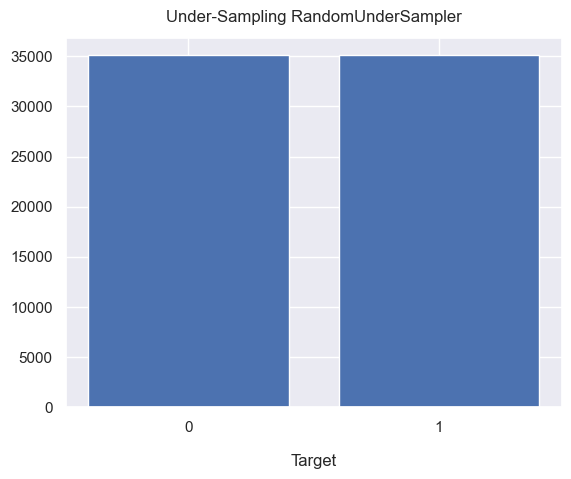

Diabetes_binary
0.0    35097
1.0    35097
Name: count, dtype: int64

In [18]:
# Under-Sampling RandomUnderSampler
sns.set(font_scale=1.0)
rus_counts = y_resampled_rus.value_counts()

plt.bar(rus_counts.index, rus_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Under-Sampling RandomUnderSampler", y=1.02);
plt.show()

rus_counts

## Over- and Under-Sampling SMOTEENN

In [19]:
# SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_resampled_smoteenn, y_resampled_smoteenn = smoteenn.fit_resample(X, y)

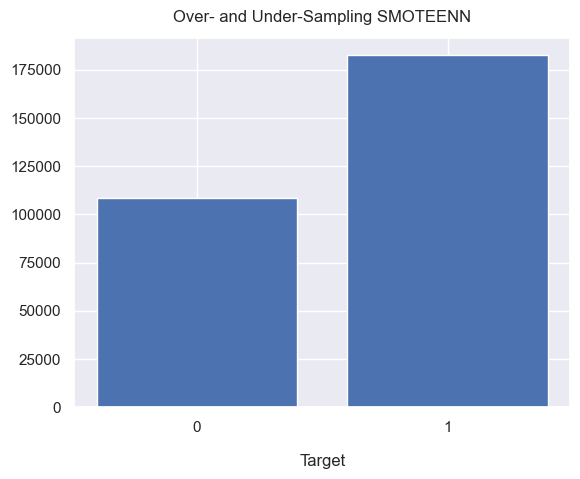

Diabetes_binary
1.0    182553
0.0    108717
Name: count, dtype: int64

In [20]:
# Over- and Under-Sampling SMOTEENN
sns.set(font_scale=1.0)
smoteenn_counts = y_resampled_smoteenn.value_counts()

plt.bar(smoteenn_counts.index, smoteenn_counts.values)
plt.xlabel("Target", labelpad=14)
plt.xticks([0, 1])
plt.title("Over- and Under-Sampling SMOTEENN", y=1.02);
plt.show()

smoteenn_counts

# Split Data

In [21]:
#Data Raw
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test), len(y_train), len(y_test)

(183579, 45895, 183579, 45895)

In [22]:
# Oversampling SMOTE
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_resampled_smote, y_resampled_smote,
                                                                            test_size=0.2, random_state=42)
len(X_train_smote), len(X_test_smote), len(y_train_smote), len(y_test_smote)

(311003, 77751, 311003, 77751)

In [23]:
# Under-Sampling RandomUnderSampler
X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(X_resampled_rus, y_resampled_rus,
                                                                    test_size=0.2, random_state=42)
len(X_train_rus), len(X_test_rus), len(y_train_rus), len(y_test_rus)

(56155, 14039, 56155, 14039)

In [24]:
# Over- and Under-Sampling SMOTEENN
X_train_smoteenn, X_test_smoteenn, y_train_smoteenn, y_test_smoteenn = train_test_split(X_resampled_smoteenn, y_resampled_smoteenn,
                                                                    test_size=0.2, random_state=42)
len(X_train_smoteenn), len(X_test_smoteenn), len(y_train_smoteenn), len(y_test_smoteenn)

(233016, 58254, 233016, 58254)

# Model

In [25]:
# Raw Data
model = xgboost.XGBClassifier()
model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [26]:
# Tính scale_pos_weight từ TRAIN SET
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight:", scale_pos_weight)

model_weighted = xgboost.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

model_weighted.fit(X_train, y_train)

scale_pos_weight: 5.552882384436908


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [27]:
# Over-Sampling SMOTE
model_smote = xgboost.XGBClassifier()
model_smote.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
# Under-Sampling RandomUnderSampler
model_rus = xgboost.XGBClassifier()
model_rus.fit(X_train_rus, y_train_rus)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [29]:
# Over and Under-Sampling SMTOEENN
model_smoteenn = xgboost.XGBClassifier()
model_smoteenn.fit(X_train_smoteenn, y_train_smoteenn)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Evaluasion

In [30]:
# Raw Data
y_test_pred = model.predict(X_test)

print("\nTest Set:")
print(classification_report(y_test, y_test_pred))

accuracy_test = accuracy_score(y_test, y_test_pred)

print("\nTest Set Accuracy:", accuracy_test)


Test Set:
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92     38813
         1.0       0.55      0.17      0.26      7082

    accuracy                           0.85     45895
   macro avg       0.71      0.57      0.59     45895
weighted avg       0.82      0.85      0.82     45895


Test Set Accuracy: 0.8500490249482514


In [31]:
# Predict probability
y_prob_weighted = model_weighted.predict_proba(X_test)[:, 1]

# Threshold = 0.5
y_pred_weighted_05 = (y_prob_weighted >= 0.5).astype(int)

print("Test Set (Class Weight – threshold 0.5):")
print(confusion_matrix(y_test, y_pred_weighted_05))
print(classification_report(y_test, y_pred_weighted_05, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_weighted_05))


Test Set (Class Weight – threshold 0.5):
[[27382 11431]
 [ 1594  5488]]
              precision    recall  f1-score   support

         0.0     0.9450    0.7055    0.8079     38813
         1.0     0.3244    0.7749    0.4573      7082

    accuracy                         0.7162     45895
   macro avg     0.6347    0.7402    0.6326     45895
weighted avg     0.8492    0.7162    0.7538     45895

Accuracy: 0.7162000217888659


In [32]:
# Over-Sampling SMOTE
y_test_pred_smote = model_smote.predict(X_test_smote)

print("\nTest Set:")
print(classification_report(y_test_smote, y_test_pred_smote))

accuracy_test_smote = accuracy_score(y_test_smote, y_test_pred_smote)

print("\nTest Set Accuracy:", accuracy_test_smote)


Test Set:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     38930
         1.0       0.97      0.85      0.90     38821

    accuracy                           0.91     77751
   macro avg       0.91      0.91      0.91     77751
weighted avg       0.91      0.91      0.91     77751


Test Set Accuracy: 0.9083098609664184


In [33]:
# Under-Sampling RandomUnderSampler
y_test_pred_rus = model_rus.predict(X_test_rus)

print("\nTest Set:")
print(classification_report(y_test_rus, y_test_pred_rus))

accuracy_test_rus = accuracy_score(y_test_rus, y_test_pred_rus)

print("\nTest Set Accuracy:", accuracy_test_rus)


Test Set:
              precision    recall  f1-score   support

         0.0       0.76      0.70      0.73      7012
         1.0       0.72      0.78      0.75      7027

    accuracy                           0.74     14039
   macro avg       0.74      0.74      0.74     14039
weighted avg       0.74      0.74      0.74     14039


Test Set Accuracy: 0.7362347745565924


In [34]:
# Over and Under-Sampling SMTOEENN
y_test_pred_smoteenn = model_smoteenn.predict(X_test_smoteenn)

print("\nTest Set:")
print(classification_report(y_test_smoteenn, y_test_pred_smoteenn))

accuracy_test_smoteenn = accuracy_score(y_test_smoteenn, y_test_pred_smoteenn)

print("\nTest Set Accuracy:", accuracy_test_smoteenn)


Test Set:
              precision    recall  f1-score   support

         0.0       0.91      0.94      0.92     21734
         1.0       0.96      0.94      0.95     36520

    accuracy                           0.94     58254
   macro avg       0.94      0.94      0.94     58254
weighted avg       0.94      0.94      0.94     58254


Test Set Accuracy: 0.9428022110069695


In [35]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_weighted)

# chọn threshold đạt recall >= 0.85
target_recall = 0.85
idx = (recall >= target_recall).nonzero()[0][-1]

best_threshold = thresholds[idx]

print("Chosen threshold:", best_threshold)
print("Recall:", recall[idx])
print("Precision:", precision[idx])


Chosen threshold: 0.41364238
Recall: 0.8500423609149957
Precision: 0.291046219299942


In [36]:
y_pred_weighted_opt = (y_prob_weighted >= best_threshold).astype(int)

print("Test Set (Class Weight + Threshold tuning):")
print(confusion_matrix(y_test, y_pred_weighted_opt))
print(classification_report(y_test, y_pred_weighted_opt, digits=4))
print("Accuracy:", accuracy_score(y_test, y_pred_weighted_opt))


Test Set (Class Weight + Threshold tuning):
[[24149 14664]
 [ 1062  6020]]
              precision    recall  f1-score   support

         0.0     0.9579    0.6222    0.7544     38813
         1.0     0.2910    0.8500    0.4336      7082

    accuracy                         0.6573     45895
   macro avg     0.6245    0.7361    0.5940     45895
weighted avg     0.8550    0.6573    0.7049     45895

Accuracy: 0.6573482950212441


# Comparison

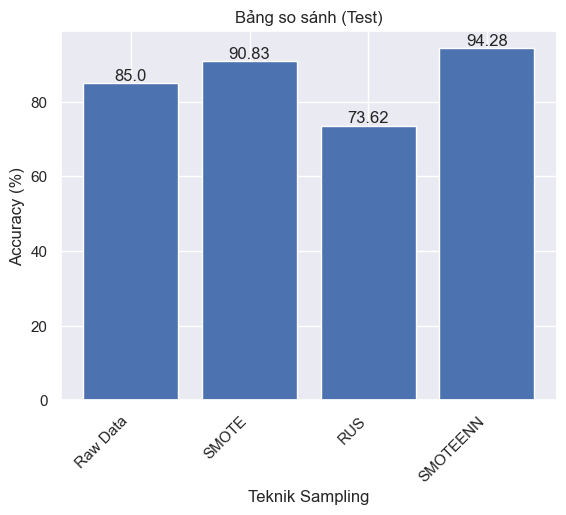

In [38]:
model_comp = pd.DataFrame({'Teknik Sampling': ['Raw Data','SMOTE','RUS', 'SMOTEENN'],
                           'Accuracy': [accuracy_test*100, accuracy_test_smote*100, accuracy_test_rus*100, accuracy_test_smoteenn*100]})

fig, ax = plt.subplots()
bars = plt.bar(model_comp['Teknik Sampling'], model_comp['Accuracy'])
plt.xlabel('Teknik Sampling')
plt.ylabel('Accuracy (%)')
plt.title('Bảng so sánh (Test)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom')

plt.show()

## Confusion Matrix

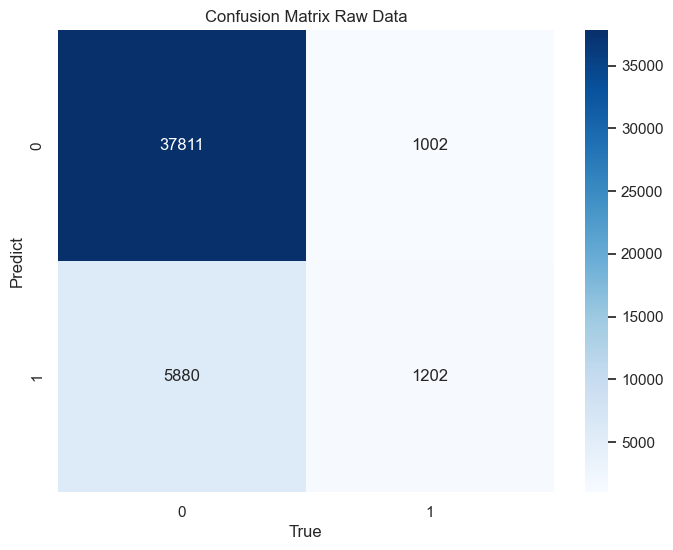

In [ ]:
# RAW DATA
cm_raw = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix Raw Data')
plt.xlabel('True')
plt.ylabel('Predict')
plt.show()

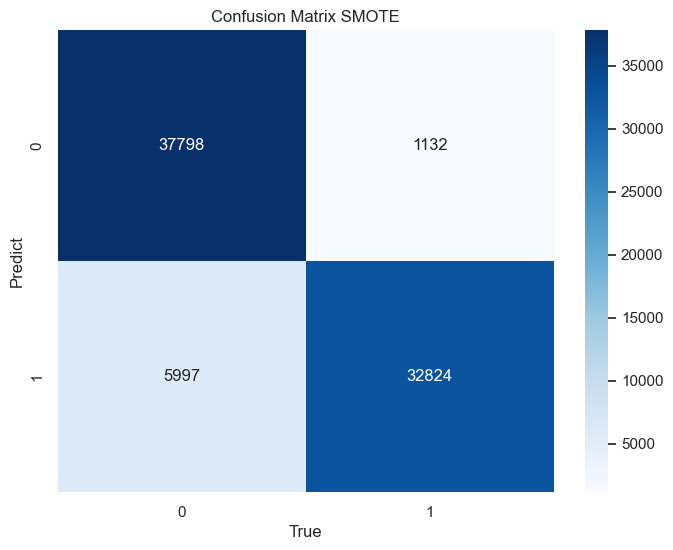

In [40]:
# SMOTE
cm_smote = confusion_matrix(y_test_smote, y_test_pred_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_smote, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix SMOTE')
plt.xlabel('True')
plt.ylabel('Predict')
plt.show()

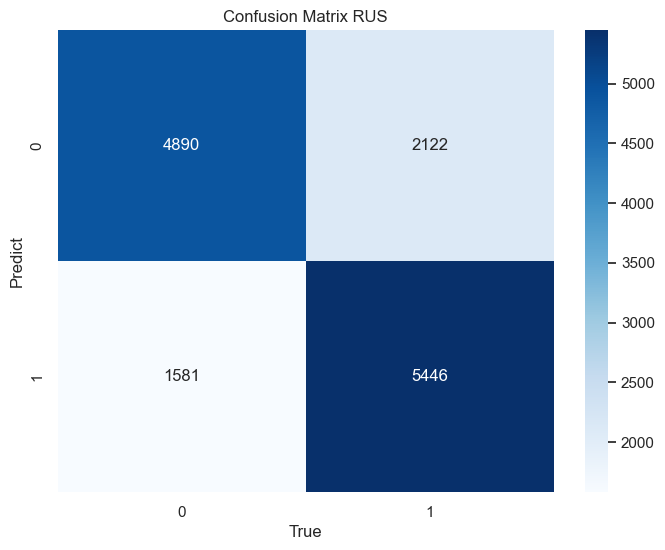

In [41]:
# RUS
cm_rus = confusion_matrix(y_test_rus, y_test_pred_rus)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rus, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix RUS')
plt.xlabel('True')
plt.ylabel('Predict')
plt.show()

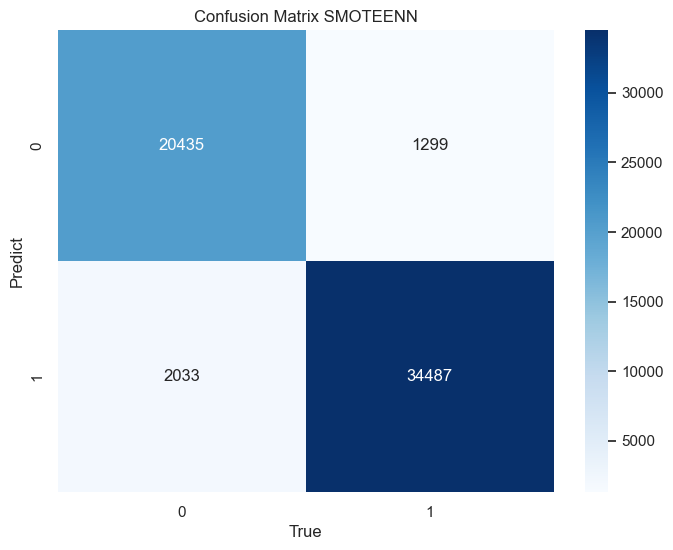

In [42]:
# SMOTEENN
cm_smoteenn = confusion_matrix(y_test_smoteenn, y_test_pred_smoteenn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_smoteenn, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix SMOTEENN')
plt.xlabel('True')
plt.ylabel('Predict')
plt.show()

In [64]:
import joblib
joblib.dump(model_smoteenn, '../../models/se/xgboost_full.pkl')

['../../models/se/xgboost_full.pkl']

In [48]:
loaded_model = joblib.load("../../models/se/xgboost_smoteenn_model.pkl")

# test predict thử 5 mẫu
y_pred_sample = loaded_model.predict(X_test[:5])
print(y_pred_sample)


[0 0 0 1 1]


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 1 Load model
loaded_model = joblib.load("../../models/se/xgboost_smoteenn_model.pkl")

# 2 Predict probability
y_prob = loaded_model.predict_proba(X_test)[:, 1]

# 3 Điều chỉnh threshold
threshold = 0.6   # 👈 bạn có thể thử 0.6 / 0.7 / 0.8
y_pred_adj = (y_prob > threshold).astype(int)

# 4 Đánh giá tổng thể
print(f"Threshold = {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_adj))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_adj))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_adj))

# 5 Test chi tiết 10 mẫu đầu
print("\n Check 10 samples đầu:")
for i in range(10):
    print(
        f"Sample {i} | "
        f"True: {y_test.iloc[i]} | "
        f"Pred: {y_pred_adj[i]} | "
        f"Prob(1): {y_prob[i]:.3f}"
    )


Threshold = 0.6
Accuracy: 0.7999128445364418

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.83      0.88     38813
         1.0       0.40      0.61      0.48      7082

    accuracy                           0.80     45895
   macro avg       0.66      0.72      0.68     45895
weighted avg       0.84      0.80      0.82     45895

Confusion Matrix:
[[32395  6418]
 [ 2765  4317]]

🔍 Check 10 samples đầu:
Sample 0 | True: 0.0 | Pred: 0 | Prob(1): 0.009
Sample 1 | True: 0.0 | Pred: 0 | Prob(1): 0.026
Sample 2 | True: 0.0 | Pred: 0 | Prob(1): 0.089
Sample 3 | True: 0.0 | Pred: 1 | Prob(1): 0.916
Sample 4 | True: 0.0 | Pred: 1 | Prob(1): 0.651
Sample 5 | True: 0.0 | Pred: 1 | Prob(1): 0.886
Sample 6 | True: 1.0 | Pred: 0 | Prob(1): 0.459
Sample 7 | True: 0.0 | Pred: 0 | Prob(1): 0.010
Sample 8 | True: 0.0 | Pred: 1 | Prob(1): 0.697
Sample 9 | True: 0.0 | Pred: 0 | Prob(1): 0.333
